<a href="https://colab.research.google.com/github/sanjana924/Predictive-Modeling-of-Nutrient-Deficiencies/blob/main/ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Mounting to Google Drive

#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

In [4]:
base_path = './data/'

# Loading NHANES datasets using Google Drive paths
files = {
    'DEMO': base_path + 'DEMO_L.xpt',
    'VID': base_path + 'VID_L.xpt',
    'FERTIN': base_path + 'FERTIN_L.xpt',
    'FOLATE': base_path + 'FOLATE_L.xpt',
    'BIOPRO': base_path + 'BIOPRO_L.xpt',
    'PAQ': base_path + 'PAQ_L.xpt',
    'DR1TOT': base_path + 'DR1TOT_L.xpt',
    'SLQ': base_path + 'SLQ_L.xpt',
    'DPQ': base_path + 'DPQ_L.xpt',
    'ALQ': base_path + 'ALQ_L.xpt'
}

# Reading datasets into dataframes
dfs = {name: pd.read_sas(file) for name, file in files.items()}

# Merging dfs on indiviual sequence number (SEQN)
# Creating a copy of DEMO as our main df to merge other dfs into (DEMO contains all of the base information)
df = dfs['DEMO'].copy()
# Looping through other dfs (excluding DEMO)
for name, d in dfs.items():
    if name != 'DEMO':
        # Selecting only new columns (plus SEQN) to prevent duplicates
        cols = d.columns.difference(df.columns).tolist() + ['SEQN']
        df = pd.merge(df, d[cols], on='SEQN', how='left')

# Filtering for adults only (>= 18 years of age)
df = df[df['RIDAGEYR'] >= 18].copy()

# Computing depression severity score
# List of the nine depression question columns (labeled DPQ010-DPQ090)
depression_score_cols = [f'DPQ0{i}0' for i in range(1, 10)]
# Replacing "Refused" (7) and "Don't Know" (9) (and any missing values) with 0 for scoring
df[depression_score_cols] = df[depression_score_cols].replace({7: 0, 9: 0, np.nan: 0})
# Summing columns to get total depression score
df['Depression_Score'] = df[depression_score_cols].sum(axis=1)

# Determining nutrient deficiencies (transforming numbers into true/false based on NHANES thresholds)
df['Deficient_VitD'] = df['LBXVIDMS'] < 30
df['Deficient_Iron'] = df['LBDFERSI'] < 15
df['Deficient_Folate'] = df['LBDRFO'] < 151
df['Deficient_Magnesium'] = df['LBXMAGN'] < 1.46

# Selecting relevant features to shorten the dataset
features_to_keep = [
    'SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1',  # Demographics
    'PAD680', 'PAD800', 'PAD820',                # Physical activity (sedentary mins, moderate mins, vig mins)
    'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TTFAT', # Diet (calories and macros)
    'SLD012',                                    # Sleep hours
    'ALQ121', 'ALQ130',                          # Alcohol frequency/amount
    'Depression_Score',                          # Mental health
    'Deficient_VitD', 'Deficient_Iron', 'Deficient_Folate', 'Deficient_Magnesium', # Deficiency binary columns
    'WTINT2YR', 'WTMEC2YR',                      # Survey weights
    'SDMVPSU', 'SDMVSTRA'                        # Stratification
]
existing_features = [col for col in features_to_keep if col in df.columns]
df_clean = df[existing_features].copy()

# Cleaning missing values
# Creating a list with numeric column names
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
# Filling missing values with the column's median value
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Capping outlying values
# List of columns with continuous variables
continuous_vars = [
    'RIDAGEYR', 'PAD680', 'PAD800', 'PAD820', 'DR1TKCAL',
    'DR1TPROT', 'DR1TCARB', 'DR1TTFAT', 'SLD012', 'ALQ130', 'Depression_Score'
]
# Making sure they exist in dataframe
continuous_vars = [c for c in continuous_vars if c in df_clean.columns]

# Capping values below 1st percentile and above 99th percentile
for col in continuous_vars:
    lower_limit = df_clean[col].quantile(0.01)
    upper_limit = df_clean[col].quantile(0.99)
    df_clean[col] = np.clip(df_clean[col], lower_limit, upper_limit)

# Reducing skew
for col in continuous_vars:
  # Check if column is extremely skewed and adjust if necessary
    if abs(skew(df_clean[col])) > 1:
        df_clean[col] = np.log1p(df_clean[col])

# Scaling continuous columns so they're normalized
# scaler = StandardScaler()
# df_clean[continuous_vars] = scaler.fit_transform(df_clean[continuous_vars])

# Categorical columns for one-hot encoding
categorical_cols = ['RIAGENDR', 'RIDRETH1']
# One-hot encoding categorical variables
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Saving cleaned dataset locally
output_path = "./data/NHANES_Cleaned_Data.csv"
df_clean.to_csv(output_path, index=False)

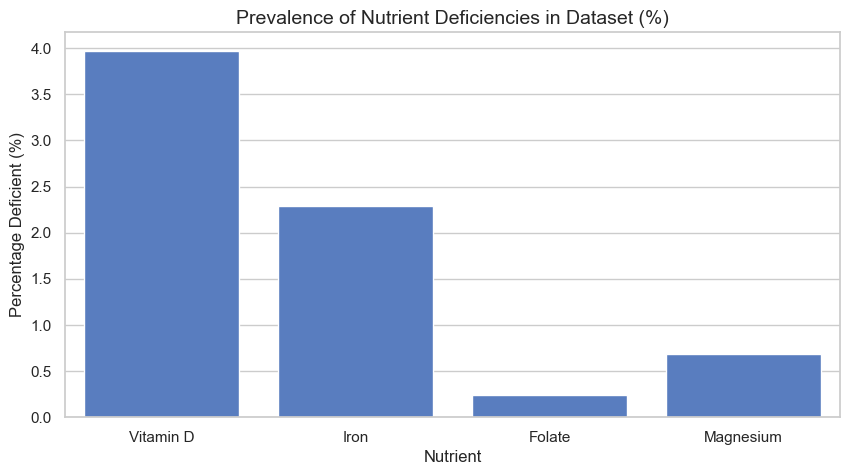

C:\Users\sanja\AppData\Local\Temp\ipykernel_24832\3849887735.py:40: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=gender_col, y='Deficient_Iron', ci=None)


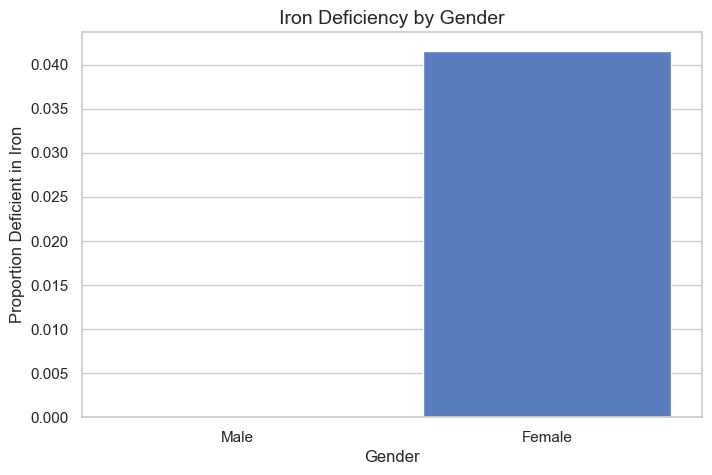

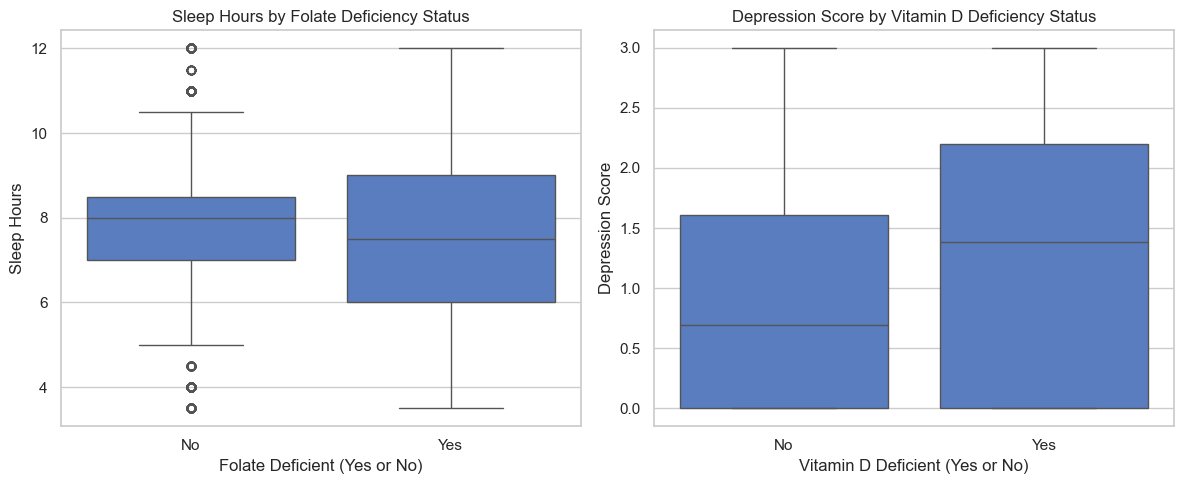

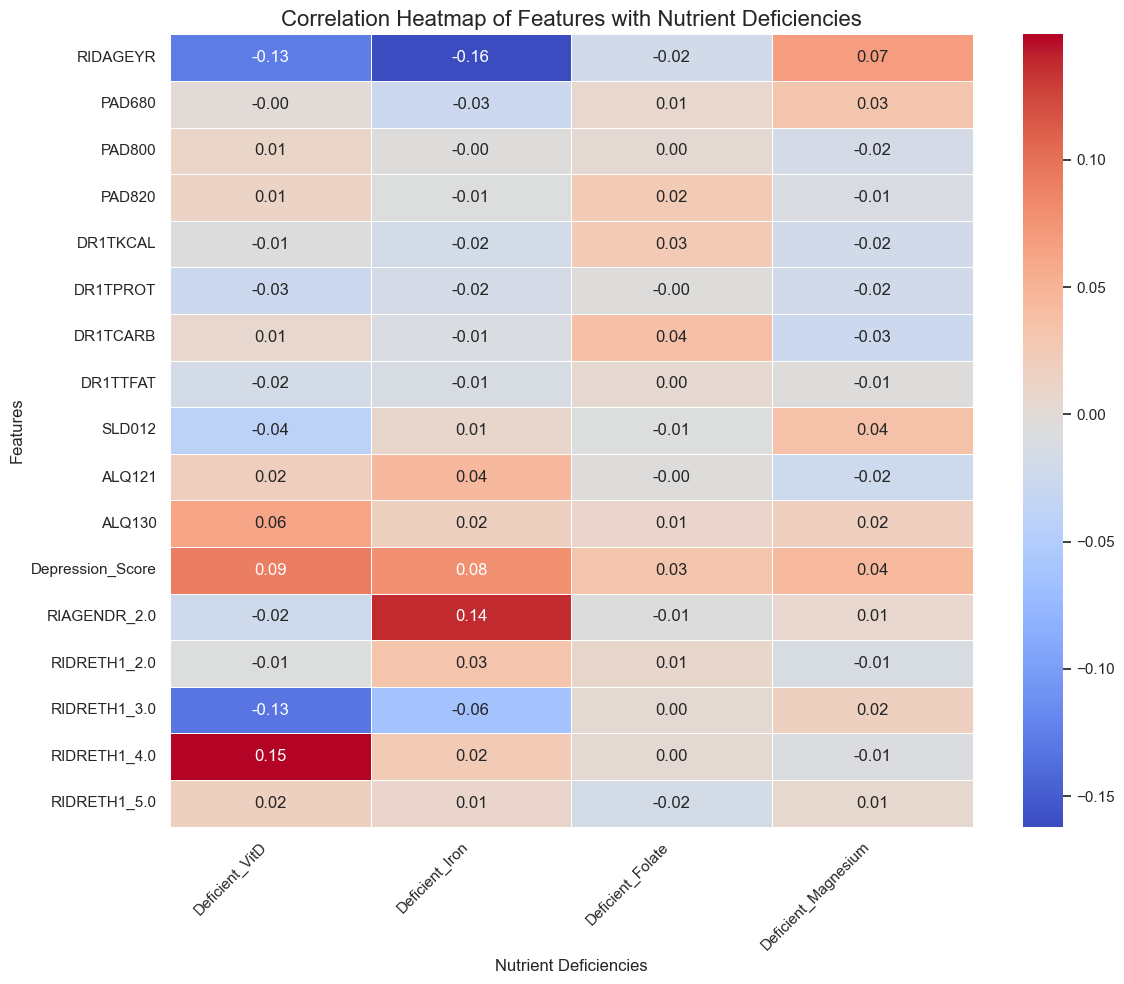

In [7]:
# Exploratory data analysis
#from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Loading the cleaned dataset from Google Drive
#drive.mount('/content/drive')
#file_path = '/content/drive/MyDrive/data/NHANES_Cleaned_Data.csv'
#df = pd.read_csv(file_path)

# Loading csv
df = pd.read_csv("./data/NHANES_Cleaned_Data.csv")

# Making sure plots appear in the notebook + good format
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

# Creating a bar graph to visualize what percent of the subjects have each deficiency
plt.figure(figsize=(10, 5))
deficiency_rates = df[['Deficient_VitD', 'Deficient_Iron', 'Deficient_Folate', 'Deficient_Magnesium']].mean() * 100
sns.barplot(x=deficiency_rates.index, y=deficiency_rates.values)
plt.title("Prevalence of Nutrient Deficiencies in Dataset (%)", fontsize=14)
plt.ylabel("Percentage Deficient (%)")
plt.xlabel("Nutrient")
plt.xticks(ticks=[0,1,2,3], labels=['Vitamin D', 'Iron', 'Folate', 'Magnesium'])
plt.show()

# Creating a bar graph to visualize iron deficiency by gender
plt.figure(figsize=(8, 5))
gender_col = 'RIAGENDR_2.0' if 'RIAGENDR_2.0' in df.columns else 'RIAGENDR'
sns.barplot(data=df, x=gender_col, y='Deficient_Iron', ci=None)
plt.title("Iron Deficiency by Gender", fontsize=14)
plt.ylabel("Proportion Deficient in Iron")
plt.xlabel("Gender")
plt.xticks([0, 1], ['Male', 'Female'])
plt.show()

# Creating a boxplot to visualize folate levels vs. sleep hours
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Deficient_Folate', y='SLD012')
plt.title("Sleep Hours by Folate Deficiency Status")
plt.xlabel("Folate Deficient (Yes or No)")
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylabel("Sleep Hours")

# Creating a boxplot to visualize folate levels vs. depression score
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Deficient_VitD', y='Depression_Score')
plt.title("Depression Score by Vitamin D Deficiency Status")
plt.xlabel("Vitamin D Deficient (Yes or No)")
plt.ylabel("Depression Score")
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

# Defining targets and features (excluding SEQN because it's a label)
targets = ['Deficient_VitD', 'Deficient_Iron', 'Deficient_Folate', 'Deficient_Magnesium']
features = [col for col in df.columns if col not in targets and col != 'SEQN' and col not in ['WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']]
# Combining features and targets for correlation matrix
df_combined = df[features + targets]
correlation_matrix = df_combined.corr()
# Extracting correlations of features with deficiencies
correlation_to_plot = correlation_matrix.loc[features, targets]

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_to_plot, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features with Nutrient Deficiencies', fontsize=16)
plt.ylabel('Features', fontsize=12)
plt.xlabel('Nutrient Deficiencies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# Machine learning and model evaluation
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# What we want to predict
targets = ['Deficient_VitD', 'Deficient_Iron', 'Deficient_Folate', 'Deficient_Magnesium']
# Creating list of feature columns (excluding SEQN because that's just a label)
features = [col for col in df.columns if col not in targets and col != 'SEQN']
X = df[features]

results = []

# Logistic Regression
print("Logistic Regression")

for target in targets:
    print(target)
    y = df[target]

    # Splitting the dataset (75% training and 25% testing)
    if len(y.unique()) < 2 or y.value_counts().min() < 2:
      continue
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

    # Model training and prediction
    logistic_regression = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    logistic_regression.fit(X_train, y_train)
    y_pred = logistic_regression.predict(X_test)

    # calculating metrics
    acc_score = accuracy_score(y_test, y_pred)
    prec_score = precision_score(y_test, y_pred, zero_division=0)
    rec_score = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Storing results
    results.append({
      'Target': target,
      'Model': 'Logistic Regression',
      'Accuracy': acc_score,
      'Precision': prec_score,
      'Recall': rec_score,
      'F1-Score': f1
    })

    # Printing confusion matrix and metrics
    cm = confusion_matrix(y_test, y_pred)
    print("Logistic Regression")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {acc_score:.4f} | Precision: {prec_score:.4f} | Recall: {rec_score:.4f} | F1-Score: {f1:.4f}")

# Support Vector Machine
print("Support Vector Machine")

for target in targets:
    print(target)
    y = df[target]

    # Splitting the dataset (75% training and 25% testing)
    if len(y.unique()) < 2 or y.value_counts().min() < 2:
      continue
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

    # Model training and prediction
    svm = LinearSVC(class_weight='balanced', random_state=42, dual=False)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    # calculating metrics
    acc_score = accuracy_score(y_test, y_pred)
    prec_score = precision_score(y_test, y_pred, zero_division=0)
    rec_score = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Storing results
    results.append({
      'Target': target,
      'Model': 'Support Vector Machine',
      'Accuracy': acc_score,
      'Precision': prec_score,
      'Recall': rec_score,
      'F1-Score': f1
    })

    # Printing confusion matrix and metrics
    cm = confusion_matrix(y_test, y_pred)
    print("Support Vector Machine")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {acc_score:.4f} | Precision: {prec_score:.4f} | Recall: {rec_score:.4f} | F1-Score: {f1:.4f}")

# Random Forest
print("Random Forest")

for target in targets:
    print(target)
    y = df[target]

    # Splitting the dataset (75% training and 25% testing)
    if len(y.unique()) < 2 or y.value_counts().min() < 2:
      continue
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

    # Model training and prediction
    random_forest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    random_forest.fit(X_train, y_train)
    y_pred = random_forest.predict(X_test)

    # Calculating metrics
    acc_score = accuracy_score(y_test, y_pred)
    prec_score = precision_score(y_test, y_pred, zero_division=0)
    rec_score = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Storing results
    results.append({
      'Target': target,
      'Model': 'Random Forest',
      'Accuracy': acc_score,
      'Precision': prec_score,
      'Recall': rec_score,
      'F1-Score': f1
    })

    # Printing confusion matrix and metrics
    cm = confusion_matrix(y_test, y_pred)
    print("Random Forest")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {acc_score:.4f} | Precision: {prec_score:.4f} | Recall: {rec_score:.4f} | F1-Score: {f1:.4f}")

# Summarizing results into a dataframe
print("OVERALL MODEL PERFORMANCE SUMMARY")
if len(results) > 0:
    results_df = pd.DataFrame(results)
    display(results_df)

Logistic Regression
Deficient_VitD


c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

Logistic Regression
Confusion Matrix:
[[1437  521]
 [  16   65]]
Accuracy: 0.7366 | Precision: 0.1109 | Recall: 0.8025 | F1-Score: 0.1949
Deficient_Iron


c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecifie

Logistic Regression
Confusion Matrix:
[[1656  336]
 [   5   42]]
Accuracy: 0.8328 | Precision: 0.1111 | Recall: 0.8936 | F1-Score: 0.1976
Deficient_Folate


c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecifie

Logistic Regression
Confusion Matrix:
[[1568  466]
 [   4    1]]
Accuracy: 0.7695 | Precision: 0.0021 | Recall: 0.2000 | F1-Score: 0.0042
Deficient_Magnesium


c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Confusion Matrix:
[[1543  482]
 [   2   12]]
Accuracy: 0.7626 | Precision: 0.0243 | Recall: 0.8571 | F1-Score: 0.0472
Support Vector Machine
Deficient_VitD
Support Vector Machine
Confusion Matrix:
[[1439  519]
 [  23   58]]
Accuracy: 0.7342 | Precision: 0.1005 | Recall: 0.7160 | F1-Score: 0.1763
Deficient_Iron
Support Vector Machine
Confusion Matrix:
[[1652  340]
 [   4   43]]
Accuracy: 0.8313 | Precision: 0.1123 | Recall: 0.9149 | F1-Score: 0.2000
Deficient_Folate
Support Vector Machine
Confusion Matrix:
[[1659  375]
 [   5    0]]
Accuracy: 0.8136 | Precision: 0.0000 | Recall: 0.0000 | F1-Score: 0.0000
Deficient_Magnesium
Support Vector Machine
Confusion Matrix:
[[1568  457]
 [   2   12]]
Accuracy: 0.7749 | Precision: 0.0256 | Recall: 0.8571 | F1-Score: 0.0497
Random Forest
Deficient_VitD
Random Forest
Confusion Matrix:
[[1957    1]
 [  81    0]]
Accuracy: 0.9598 | Precision: 0.0000 | Recall: 0.0000 | F1-Score: 0.0000
Deficient_Iron
Random Forest
Confusion Matrix:


,Target,Model,Accuracy,Precision,Recall,F1-Score
0,Deficient_VitD,Logistic Regression,0.736636,0.110922,0.802469,0.194903
1,Deficient_Iron,Logistic Regression,0.832761,0.111111,0.893617,0.197647
2,Deficient_Folate,Logistic Regression,0.769495,0.002141,0.200000,0.004237
3,Deficient_Magnesium,Logistic Regression,0.762629,0.024291,0.857143,0.047244
4,Deficient_VitD,Support Vector Machine,0.734183,0.100520,0.716049,0.176292
5,Deficient_Iron,Support Vector Machine,0.831290,0.112272,0.914894,0.200000
6,Deficient_Folate,Support Vector Machine,0.813634,0.000000,0.000000,0.000000
7,Deficient_Magnesium,Support Vector Machine,0.774890,0.025586,0.857143,0.049689
8,Deficient_VitD,Random Forest,0.959784,0.000000,0.000000,0.000000
9,Deficient_Iron,Random Forest,0.976949,0.000000,0.000000,0.000000


c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


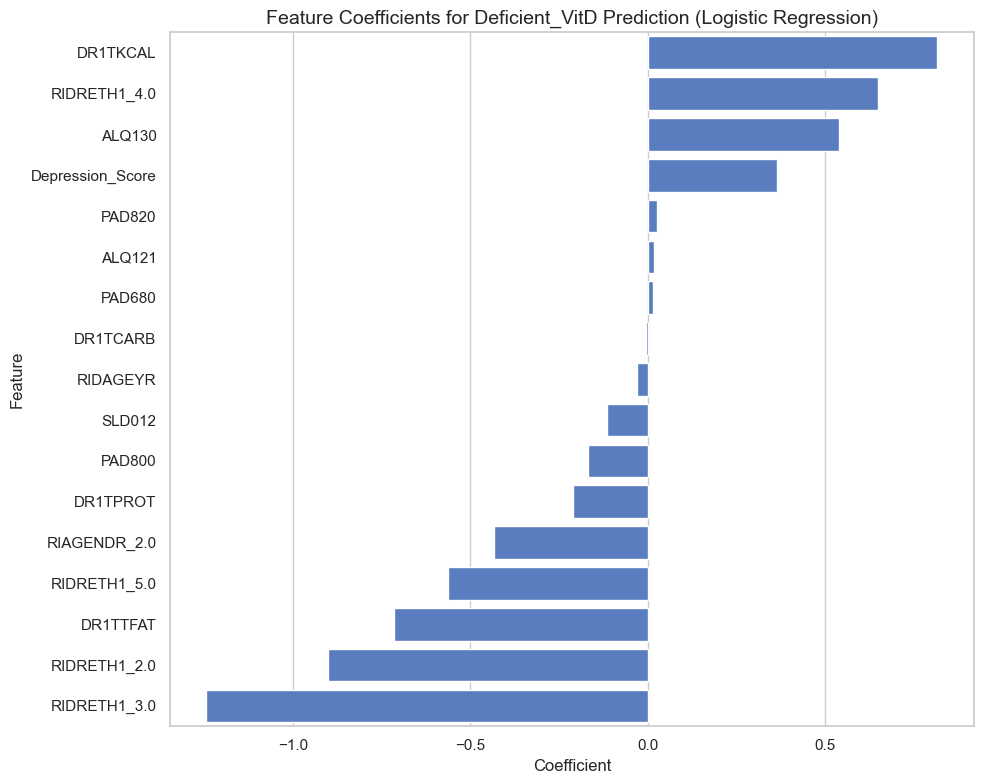

c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

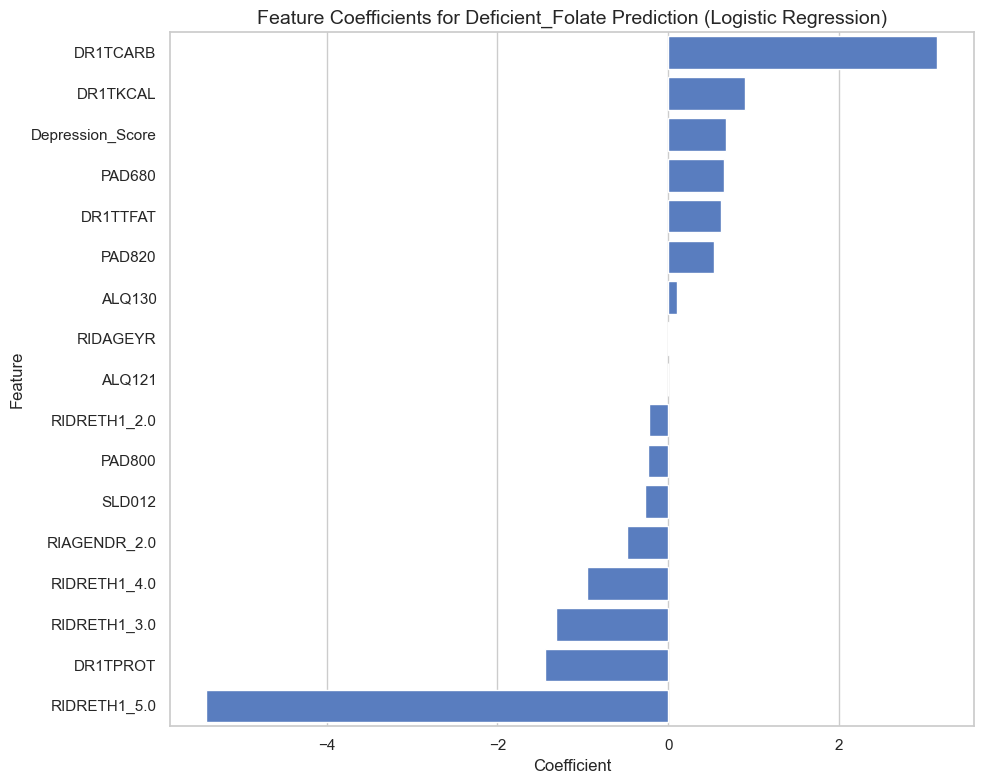

c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


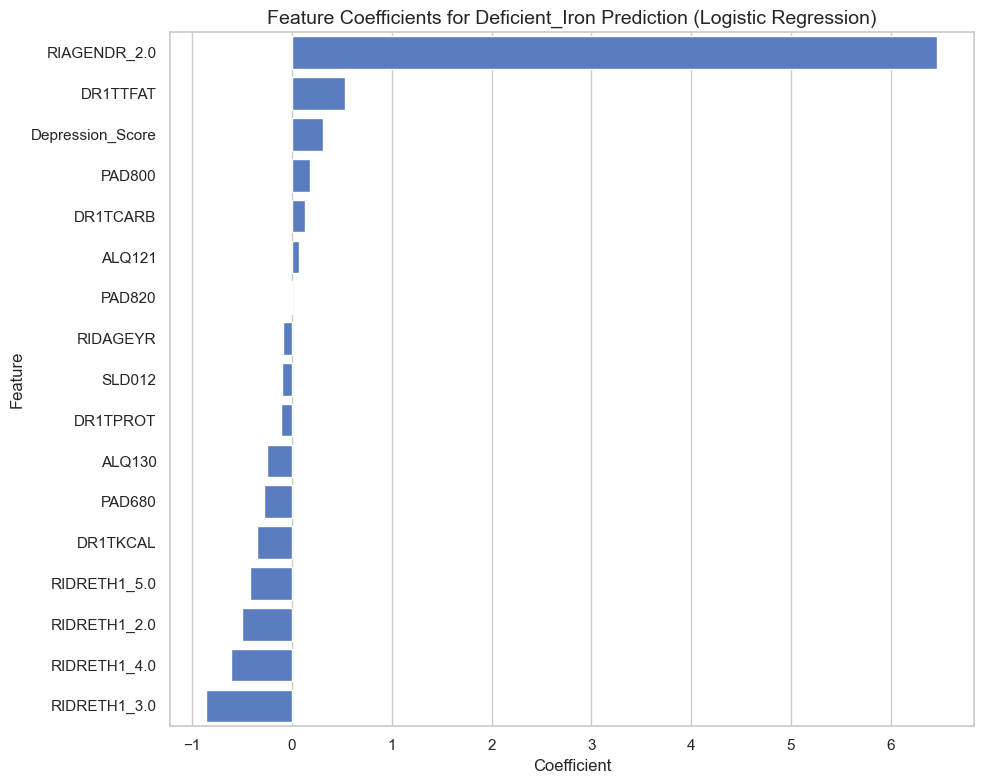

c:\Users\sanja\OneDrive\Desktop\Spring 2026\Introduction to Data Science\Predictive-Modeling-of-Nutrient-Deficiencies\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


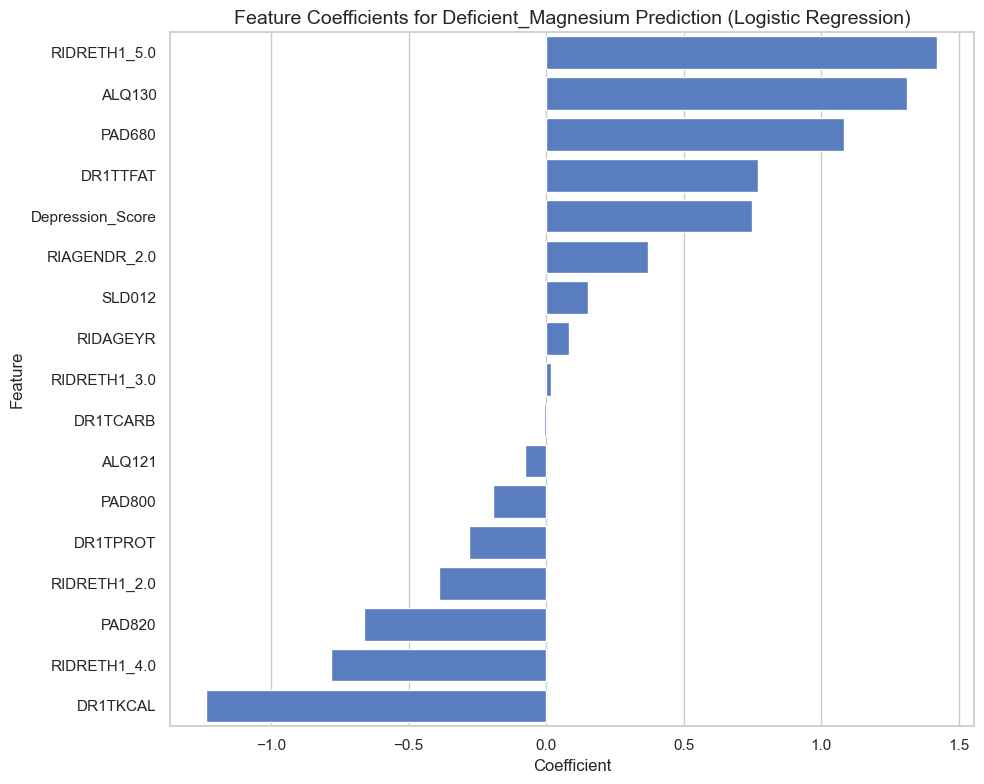

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Initializing a list to store feature importances for all targets
all_feature_importances = []

# Defining target and features for Vitamin D deficiency
target = 'Deficient_VitD'
features = [col for col in df.columns if col not in targets and col != 'SEQN' and col not in ['WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']]
X = df[features]
y = df[target]

# Checking if the target has more than one meaningful class (skipping graph if not)
if len(y.unique()) < 2 or y.value_counts().min() < 2:
    print(f"Skipping feature importance for {target}: Target does not have enough class variation.")
else:
    # Splitting data for training the model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
    # Training Logistic Regression for feature importance
    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    lr_model.fit(X_train, y_train)

    # Getting feature coefficients
    coefficients = lr_model.coef_[0]
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
    feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)
    all_feature_importances.append(feature_importance_df)

    # Plotting feature importance
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df)
    plt.title(f'Feature Coefficients for {target} Prediction (Logistic Regression)', fontsize=14)
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


# Defining target and features for Folate deficiency
target = 'Deficient_Folate'
X = df[features]
y = df[target]

# Checking if the target has more than one meaningful class (skipping graph if not)
if len(y.unique()) < 2 or y.value_counts().min() < 2:
    print(f"Skipping feature importance for {target}: Target does not have enough class variation.")
else:
    # Splitting data for training the model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
    # Training Logistic Regression for feature importance
    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    lr_model.fit(X_train, y_train)

    # Getting feature coefficients
    coefficients = lr_model.coef_[0]
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
    feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)
    all_feature_importances.append(feature_importance_df)

    # Plotting feature importance
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df)
    plt.title(f'Feature Coefficients for {target} Prediction (Logistic Regression)', fontsize=14)
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


# Defining target and features for Iron deficiency
target = 'Deficient_Iron'
X = df[features]
y = df[target]

# Checking if the target has more than one meaningful class (skipping graph if not)
if len(y.unique()) < 2 or y.value_counts().min() < 2:
    print(f"Skipping feature importance for {target}: Target does not have enough class variation.")
else:
    # Splitting data for training the model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
    # Training Logistic Regression for feature importance
    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    lr_model.fit(X_train, y_train)

    # Getting feature coefficients
    coefficients = lr_model.coef_[0]
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
    feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)
    all_feature_importances.append(feature_importance_df)

    # Plotting feature importance
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df)
    plt.title(f'Feature Coefficients for {target} Prediction (Logistic Regression)', fontsize=14)
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


# Defining target and features for Magnesium deficiency
target = 'Deficient_Magnesium'
X = df[features]
y = df[target]

# Checking if the target has more than one meaningful class (skipping graph if not)
if len(y.unique()) < 2 or y.value_counts().min() < 2:
    print(f"Skipping feature importance for {target}: Target does not have enough class variation.")
else:
    # Splitting data for training the model
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

    # Training Logistic Regression for feature importance
    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    lr_model.fit(X_train, y_train)
    # Getting feature coefficients
    coefficients = lr_model.coef_[0]
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
    feature_importance_df = feature_importance_df.sort_values(by='Coefficient', ascending=False)
    all_feature_importances.append(feature_importance_df)

    # Plotting feature importance
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df)
    plt.title(f'Feature Coefficients for {target} Prediction (Logistic Regression)', fontsize=14)
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [10]:
final_feature_importance_df = pd.DataFrame()

for i, importance_df in enumerate(all_feature_importances):
    # Adding a 'target' column to identify which nutrient this feature importance belongs to
    importance_df['Target'] = targets[i]
    final_feature_importance_df = pd.concat([final_feature_importance_df, importance_df])

# Calculating the absolute coefficient for each feature across all targets
final_feature_importance_df['Absolute_Coefficient'] = final_feature_importance_df['Coefficient'].abs()

# Grouping by feature and summing the absolute coefficients to get an overall importance score
overall_importance = final_feature_importance_df.groupby('Feature')['Absolute_Coefficient'].sum().reset_index()
overall_importance = overall_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nOverall Ranking of Feature Importance Across All Nutrient Deficiencies (based on sum of absolute Logistic Regression coefficients):")
display(overall_importance.head(20)) # Displaying top 20 features


Overall Ranking of Feature Importance Across All Nutrient Deficiencies (based on sum of absolute Logistic Regression coefficients):


,Feature,Absolute_Coefficient
15,RIDRETH1_5.0,7.819372
10,RIAGENDR_2.0,7.752332
13,RIDRETH1_3.0,3.440092
3,DR1TKCAL,3.310055
2,DR1TCARB,3.299524
14,RIDRETH1_4.0,2.988980
5,DR1TTFAT,2.643343
1,ALQ130,2.208126
6,Depression_Score,2.108229
4,DR1TPROT,2.042222


C:\Users\sanja\AppData\Local\Temp\ipykernel_24832\2511245755.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Coefficient', y='Feature', data=overall_importance.head(15), palette='viridis')


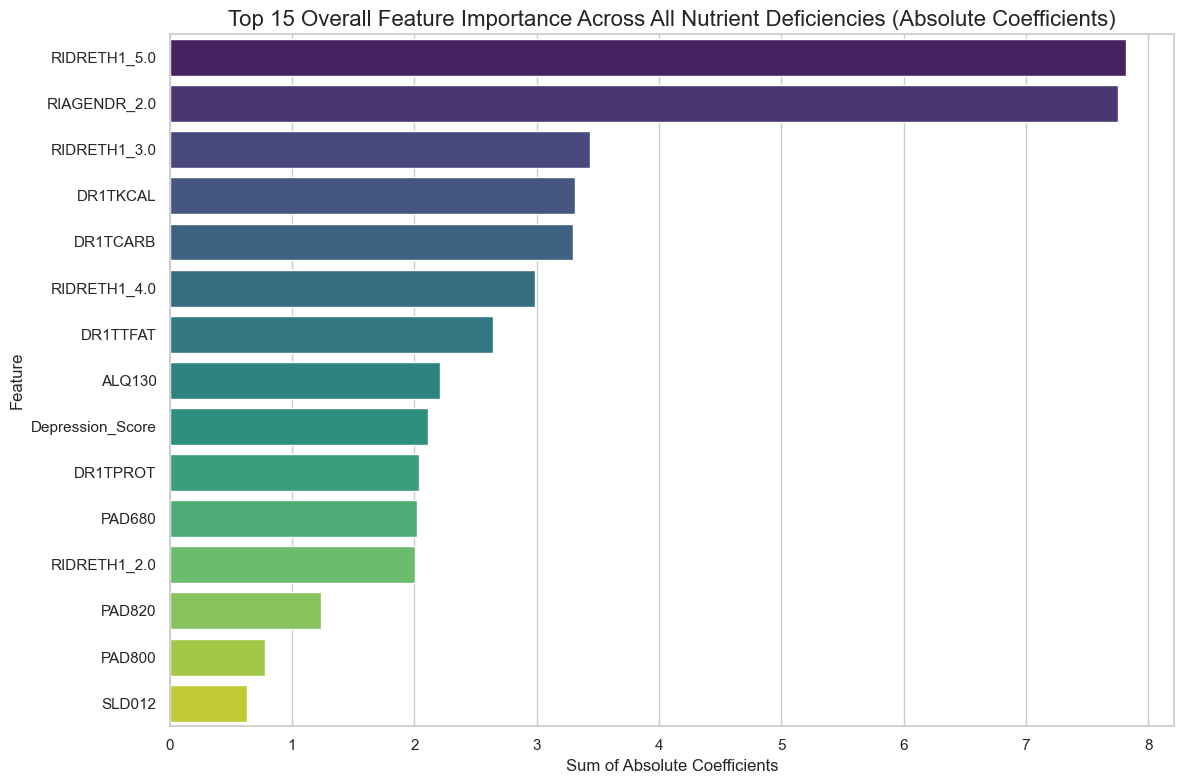

In [11]:
# Visualizing the overall feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=overall_importance.head(15), palette='viridis')
plt.title('Top 15 Overall Feature Importance Across All Nutrient Deficiencies (Absolute Coefficients)', fontsize=16)
plt.xlabel('Sum of Absolute Coefficients', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()